In [1]:
import pandas as pd
import matplotlib as plt
import seaborn as sns


In [97]:
#lendo o banco
df = pd.read_csv('conflitos.csv')

In [3]:
#quais são as colunas do banco?
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2752 entries, 0 to 2751
Data columns (total 28 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   conflict_id           2752 non-null   int64  
 1   location              2752 non-null   object 
 2   side_a                2752 non-null   object 
 3   side_a_id             2752 non-null   object 
 4   side_a_2nd            455 non-null    object 
 5   side_b                2752 non-null   object 
 6   side_b_id             2752 non-null   object 
 7   side_b_2nd            143 non-null    object 
 8   incompatibility       2752 non-null   int64  
 9   territory_name        1551 non-null   object 
 10  year                  2752 non-null   int64  
 11  intensity_level       2752 non-null   int64  
 12  cumulative_intensity  2752 non-null   int64  
 13  type_of_conflict      2752 non-null   int64  
 14  start_date            2752 non-null   object 
 15  start_prec           

In [98]:
#Substituindo os graus de incompatibilidade pelo que significam
df['incompatibility'] = df['incompatibility'].replace(1, 'territory')
df['incompatibility'] = df['incompatibility'].replace(2, 'government')
df['incompatibility'] = df['incompatibility'].replace(3, 'government and territory')

In [99]:
#Substituindo os graus de tipo de conflito pelo que significam
df['type_of_conflict'] = df['type_of_conflict'].replace(1, 'extrasystemic')
df['type_of_conflict'] = df['type_of_conflict'].replace(2, 'interstate')
df['type_of_conflict'] = df['type_of_conflict'].replace(3, 'intrastate')
df['type_of_conflict'] = df['type_of_conflict'].replace(4, 'internationalized intrastate')

In [100]:
#Substituindo os graus de intensidade de conflito pelo que significam
df['intensity_level'] = df['intensity_level'].replace(1, 'minor')
df['intensity_level'] = df['intensity_level'].replace(2, 'war')

In [62]:
#qual é o ano mais recente?

ano = df['year'].max()
print(ano)

2024


In [101]:
#qual é o motivo mais comum de guerra no mundo?
territorio = df[df['incompatibility'] == 'territory']['incompatibility'].count()
governo = df[df['incompatibility'] == 'government']['incompatibility'].count()
ambos = df[df['incompatibility'] == 'government and territory']['incompatibility'].count()
print(f'conflitos por territorio: {territorio}')
print(f'conflitos por governo: {governo}')
print(f'conflitos por ambos: {ambos}')

conflitos por territorio: 1524
conflitos por governo: 1201
conflitos por ambos: 27


array([<Axes: title={'center': 'Tipos de Incompatibilidade nos Conflitos'}, ylabel='count'>],
      dtype=object)

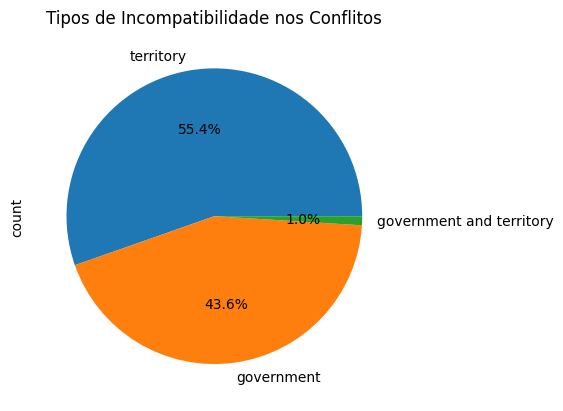

In [102]:
#qual é a proporção das incompatibilidades dos conflitos?
incompatibilidade = df['incompatibility'].value_counts()
plt.title("Tipos de Incompatibilidade nos Conflitos")
incompatibilidade.plot(kind= 'pie', subplots=True, autopct='%1.1f%%')

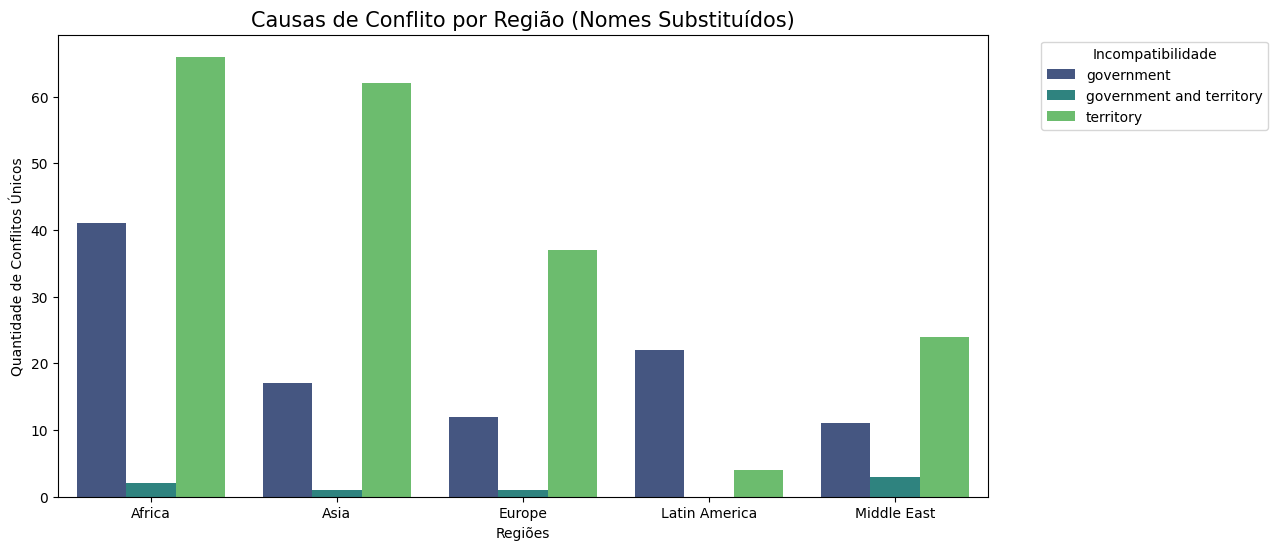

In [125]:
import numpy as np

df['regioes_nomes'] = np.where(df['regioes'].astype(str).str.contains('1'), 'Europe',
                      np.where(df['regioes'].astype(str).str.contains('2'), 'Middle East',
                      np.where(df['regioes'].astype(str).str.contains('3'), 'Asia',
                      np.where(df['regioes'].astype(str).str.contains('4'), 'Africa',
                      np.where(df['regioes'].astype(str).str.contains('5'), 'Latin America', '?')))))

df_explodido = df.explode('regioes')

resumo = df_explodido.groupby(['regioes_nomes', 'incompatibility'])['conflict_id'].nunique().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=resumo, x="regioes_nomes", y="conflict_id", hue="incompatibility", palette="viridis")
plt.title('Causas de Conflito por Região (Nomes Substituídos)', fontsize=15)
plt.xlabel('Regiões')
plt.ylabel('Quantidade de Conflitos Únicos')
plt.legend(title='Incompatibilidade', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()
plt.show()

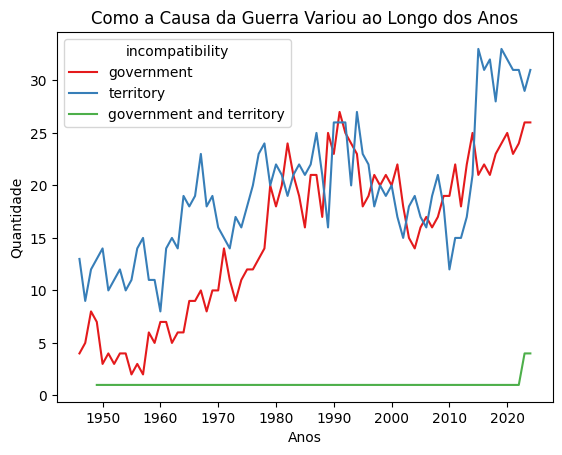

<Figure size 1200x600 with 0 Axes>

In [126]:
#como a causa das guerras mudou ao longo das decadas?
resumo_causas = df.groupby(['year', 'incompatibility'])['conflict_id'].nunique().reset_index()
sns.lineplot(data=resumo_causas, x='year', y='conflict_id', hue='incompatibility', palette='Set1')
plt.title("Como a Causa da Guerra Variou ao Longo dos Anos")
plt.xlabel("Anos")
plt.ylabel("Quantidade")
plt.figure(figsize=(12, 6))
plt.show()

In [104]:
#quantos conflitos unicos por ano tivemos?
guerras_recentes = df[(df['year'] > 2010) & (df['intensity_level'] == 'war')]
print("guerras dos ultimos anos")
tabela_resumo = guerras_recentes.groupby('year')['conflict_id'].nunique().reset_index()
tabela_resumo.columns = ['ano', 'qtd_conflitos']
print(tabela_resumo)

guerras dos ultimos anos
     ano  qtd_conflitos
0   2011              7
1   2012              6
2   2013              7
3   2014             13
4   2015             11
5   2016             12
6   2017             10
7   2018              6
8   2019              7
9   2020              8
10  2021              5
11  2022              8
12  2023              9
13  2024             11


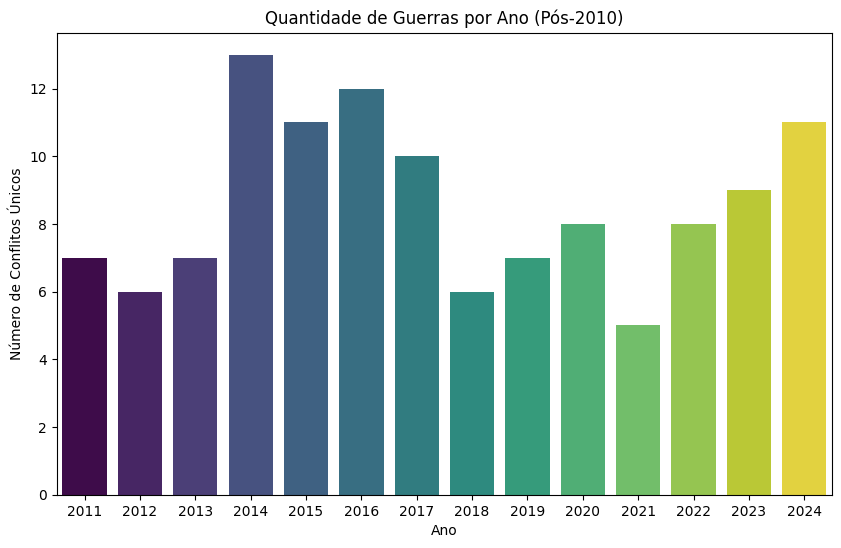

In [105]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.barplot(data=tabela_resumo, x='ano', y='qtd_conflitos', palette='viridis', hue='ano', legend=False)
plt.title('Quantidade de Guerras por Ano (Pós-2010)')
plt.xlabel('Ano')
plt.ylabel('Número de Conflitos Únicos')
plt.show()

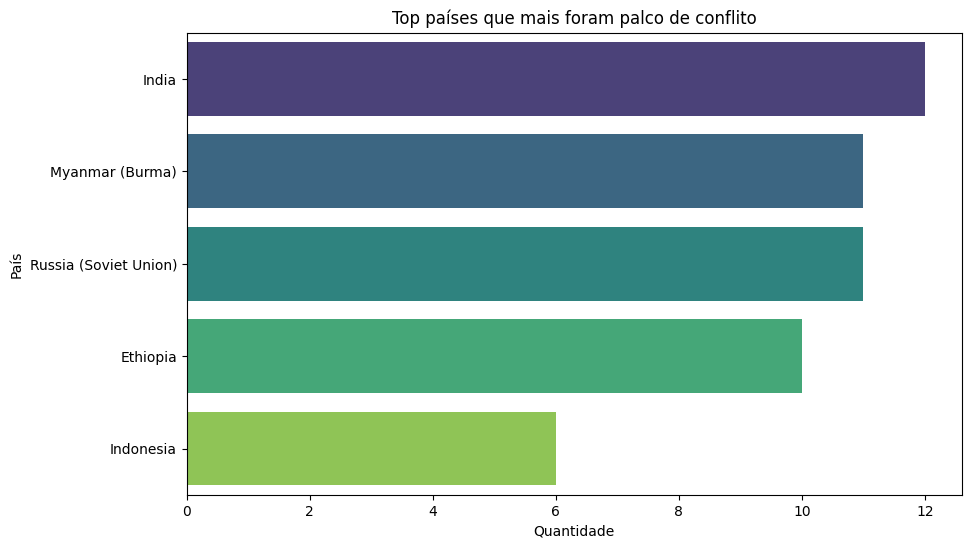

In [106]:
#quais são os 10 países/locais (location) que
#  tiveram mais registros de conflitos 
# em toda a história do dataset.
paises_conflitos = df.groupby('location')['conflict_id'].nunique().sort_values(ascending= False).head()
plt.figure(figsize=(10, 6))
sns.barplot(x = paises_conflitos.values, y = paises_conflitos.index, hue = paises_conflitos.index, palette = 'viridis')
plt.title("Top países que mais foram palco de conflito")
plt.xlabel("Quantidade")
plt.ylabel("País")
plt.show()

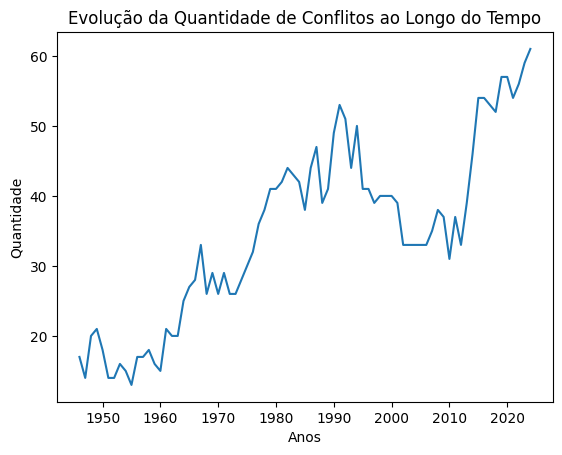

In [107]:
#grafico de linhas que mostre a linha do tempo dos conflitos
conflitos = df.groupby('year')['conflict_id'].nunique().reset_index()
sns.lineplot(data = conflitos, x = 'year', y = 'conflict_id')
plt.title("Evolução da Quantidade de Conflitos ao Longo do Tempo")
plt.xlabel("Anos")
plt.ylabel("Quantidade")
plt.show()

In [108]:
#quais são os 5 conflitos mais longos do dataset?
df['start_date'] = pd.to_datetime(df['start_date'])
df['ep_end_date'] = pd.to_datetime(df['ep_end_date'])
df['start_date'] = df['start_date'].dt.year
df['ep_end_date'] = df['ep_end_date'].dt.year

df['duracao'] = df['ep_end_date'] - df['start_date']
mais_longos = df.groupby(['conflict_id', 'location'])['year'].agg(['min', 'max']).reset_index()
mais_longos['duracao_anos'] = mais_longos['max'] - mais_longos['min']
df.drop(columns= 'duracao')
top5 = mais_longos.sort_values(by='duracao_anos', ascending=False).head()
print(top5)


    conflict_id             location   min   max  duracao_anos
9           209          Philippines  1946  2024            78
30          230  Yemen (North Yemen)  1948  2024            76
23          223      Myanmar (Burma)  1948  2024            76
22          222      Myanmar (Burma)  1948  2024            76
27          227                India  1948  2024            76


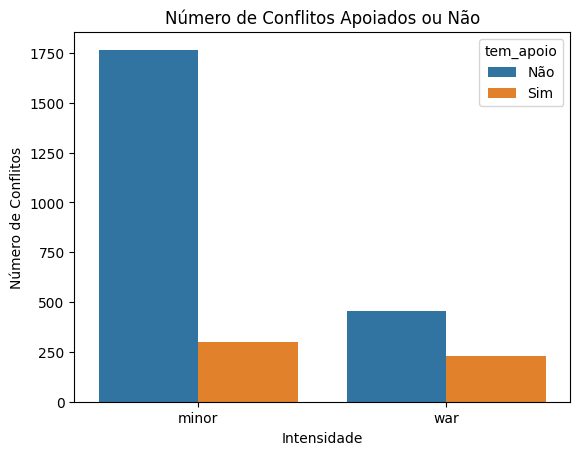

In [109]:
import numpy as np
#os conflitos que têm apoio são mais violentos?
df['tem_apoio'] = 'Não'
df['tem_apoio'] = np.where((df['side_a_2nd'].notna()) | (df['side_b_2nd'].notna()), 'Sim', 'Não')
df8 = df[['tem_apoio', 'intensity_level', 'type_of_conflict']]
sns.countplot(data=df8, x="intensity_level", hue="tem_apoio")
plt.title('Número de Conflitos Apoiados ou Não')
plt.xlabel('Intensidade')
plt.ylabel('Número de Conflitos')
plt.show()

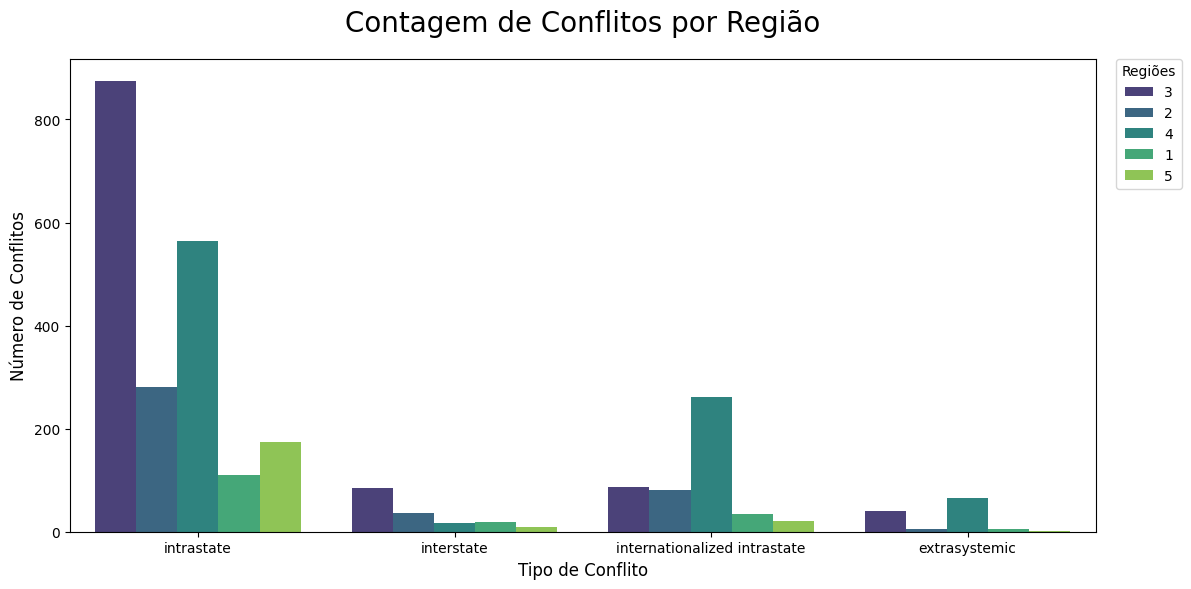

In [123]:
mapa_regioes = {'1': 'Europa', '2': 'Oriente Médio', '3': 'Ásia', '4': 'África', '5': 'Américas'}
df['regioes'] = df['region'].astype(str).str.split(', ')
df_explodido = df.explode('regioes')
df10 = df_explodido[['conflict_id', 'type_of_conflict', 'regioes']]
plt.figure(figsize=(12, 6))

sns.countplot(data=df10, x='type_of_conflict', hue='regioes', palette='viridis')
plt.title('Contagem de Conflitos por Região', fontsize=20, pad=20)
plt.xlabel('Tipo de Conflito', fontsize=12)
plt.ylabel('Número de Conflitos', fontsize=12)
plt.legend(title='Regiões', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.tight_layout() 
plt.show()


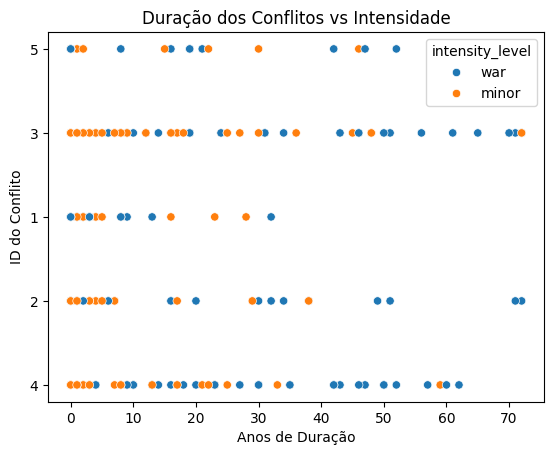

In [124]:
#Crie um gráfico de Dispersão (Scatter Plot)
#relacionando a duração do conflito com a intensidade.

df11 = df[['conflict_id', 'intensity_level','duracao', 'regioes']]
df12 = df_explodido.explode('region')
resumo = df12.groupby('conflict_id')[['duracao', 'intensity_level', 'regioes']].max().reset_index()
sns.scatterplot(data=resumo, x='duracao', y='regioes', hue='intensity_level')
plt.title('Duração dos Conflitos vs Intensidade')
plt.xlabel('Anos de Duração')
plt.ylabel('ID do Conflito')
plt.show()


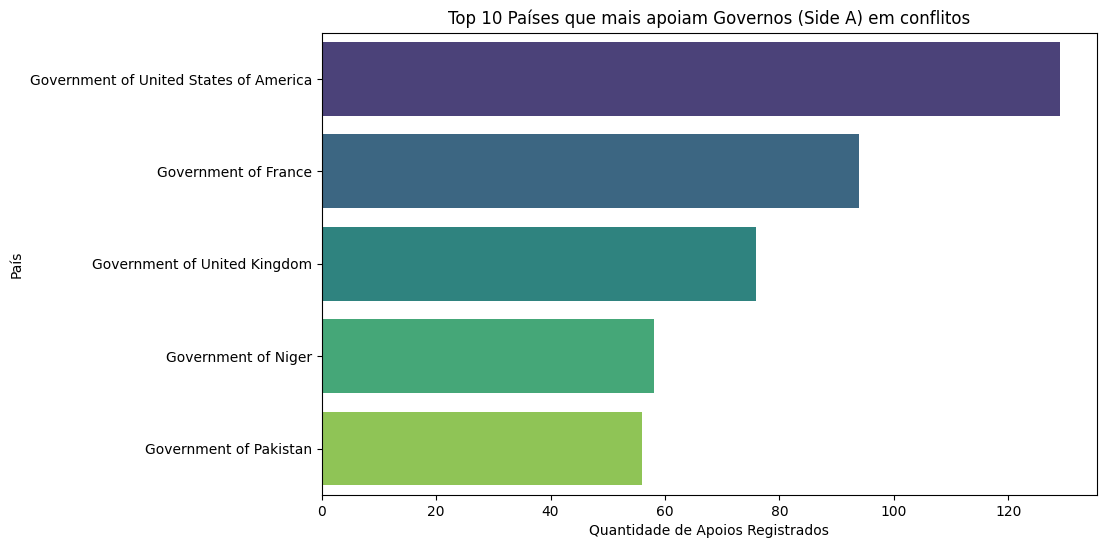

In [112]:
#quais países mais apoiam conflitos?
apoio_a = df[df['side_a_2nd'].notna()].copy()
apoio_a['paises_apoio_a'] = apoio_a['side_a_2nd'].str.split(', ')
paises_expandidos_a = apoio_a.explode('paises_apoio_a')
ranking_a = paises_expandidos_a['paises_apoio_a'].value_counts().head()
plt.figure(figsize=(10, 6))
sns.barplot(x=ranking_a.values, y=ranking_a.index, hue=ranking_a.index, palette='viridis')

# Perfumaria para o gráfico ficar bonito
plt.title('Top 10 Países que mais apoiam Governos (Side A) em conflitos')
plt.xlabel('Quantidade de Apoios Registrados')
plt.ylabel('País')
plt.show()


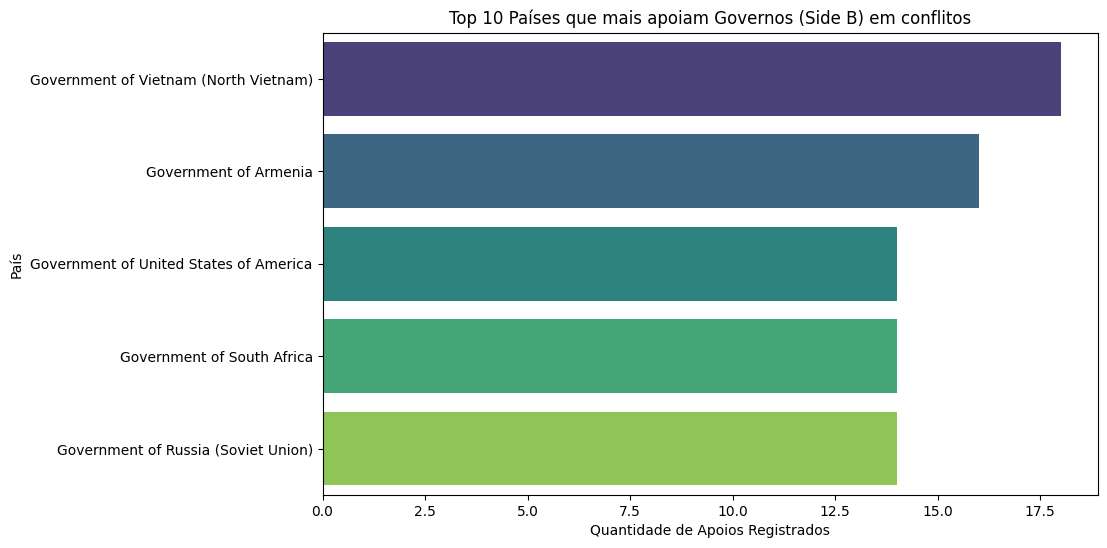

In [113]:
apoio_b = df[df['side_b_2nd'].notna()].copy()
apoio_b['paises_apoio_b'] = apoio_b['side_b_2nd'].str.split(', ')
paises_expandidos_b = apoio_b.explode('paises_apoio_b')
ranking_b = paises_expandidos_b['paises_apoio_b'].value_counts().head()
plt.figure(figsize=(10, 6))
sns.barplot(x=ranking_b.values, y=ranking_b.index, hue = ranking_b.index, palette='viridis')

# Perfumaria para o gráfico ficar bonito
plt.title('Top 10 Países que mais apoiam Governos (Side B) em conflitos')
plt.xlabel('Quantidade de Apoios Registrados')
plt.ylabel('País')
plt.show()


In [114]:
filtro = df[(df['intensity_level']== 'minor') & (df['cumulative_intensity'] == 1) & (df['year'] == 2024)]
print("Conflitos menores que a guerra e com mais de 1000 mortes em 2024")
filtro.groupby('location')['conflict_id'].nunique().sort_values(ascending= False)

Conflitos menores que a guerra e com mais de 1000 mortes em 2024


location
Myanmar (Burma)             4
Cameroon                    2
DR Congo (Zaire)            2
India                       2
Philippines                 2
Nigeria                     2
Niger                       2
Mali                        2
Afghanistan                 2
Ethiopia                    1
Colombia                    1
Burundi                     1
Central African Republic    1
Burkina Faso                1
Iran, Israel                1
Iraq                        1
Indonesia                   1
Mozambique                  1
Iran                        1
Pakistan                    1
Rwanda                      1
Syria                       1
Thailand                    1
Turkey                      1
Yemen (North Yemen)         1
Name: conflict_id, dtype: int64

In [115]:
#tipo de conflito mais comum
df.groupby('type_of_conflict')['conflict_id'].nunique().sort_values(ascending= False)

type_of_conflict
intrastate                      213
internationalized intrastate     81
interstate                       52
extrasystemic                    21
Name: conflict_id, dtype: int64

In [116]:
#1= extrasystemic (between a state and a non-state 
# group outside its own territory, where the
# government side is fighting to retain control of a
# territory outside the state system)
print("paises mais envolvidos em guerras extrasistemicas: ")
extrasistemica = df[df['type_of_conflict'] == "extrasystemic"]
pais = extrasistemica.groupby('side_a')['conflict_id'].nunique().sort_values(ascending = False)
pais.head()

paises mais envolvidos em guerras extrasistemicas: 


side_a
Government of France            9
Government of United Kingdom    6
Government of Portugal          3
Government of Netherlands       1
Government of Spain             1
Name: conflict_id, dtype: int64

In [117]:
#2= interstate (both sides are states in the Gleditsch
# and Ward membership system).
print("paises mais envolvidos em guerras entre Estados como lado A")
interstate = df[df['type_of_conflict'] == 'interstate']
pais = interstate.groupby('side_a')['conflict_id'].nunique().sort_values(ascending= False)
pais.head(5)

paises mais envolvidos em guerras entre Estados como lado A


side_a
Government of China                   5
Government of Afghanistan             3
Government of Egypt                   3
Government of Chad                    2
Government of Cambodia (Kampuchea)    2
Name: conflict_id, dtype: int64

In [118]:
#ranking por anos de guerra acumulados
paises_guerra = df[df['intensity_level'] == 'war']
top5 = paises_guerra['location'].value_counts()
print("países que mais acumulam anos de guerra:")
top5.head()

países que mais acumulam anos de guerra:


location
Myanmar (Burma)    52
Afghanistan        45
Sudan              38
Ethiopia           35
Angola             25
Name: count, dtype: int64

In [17]:
#conflitos unicos
print("\nRanking por qtd de conflitos distintos:")
ranking_conflitos = paises_guerra.groupby('location')['conflict_id'].nunique().sort_values(ascending=False)
print(ranking_conflitos.head(5))


Ranking por qtd de conflitos distintos:
location
Ethiopia                 6
Indonesia                4
Myanmar (Burma)          4
Russia (Soviet Union)    3
Nigeria                  3
Name: conflict_id, dtype: int64


In [119]:
#no pais top 1 que teve mais guerra, qual foi o motivo principal?
pais = df[(df['intensity_level'] == 'war') & (df['location'] == 'Myanmar (Burma)')]
top1 = pais.groupby('incompatibility')['conflict_id'].nunique().sort_values(ascending= False)
print("No país que teve mais guerra, qual foi a maior incompatibilidade? \n")
print(top1)

No país que teve mais guerra, qual foi a maior incompatibilidade? 

incompatibility
territory     3
government    1
Name: conflict_id, dtype: int64


In [120]:
#vezes em que Israel é mencionado em guerras
israel = df[(df['intensity_level'] == 'war') & (
    (df['side_a'].str.contains('Government of Israel', na=False)) |
    (df['side_b'].str.contains('Government of Israel', na=False)) |
    (df['side_a_2nd'].str.contains('Government of Israel', na=False)) |
    (df['side_b_2nd'].str.contains('Government of Israel', na=False))
    )]
print(f"Israel aparece {israel['conflict_id'].nunique()} vezes como uma das partes de guerras")


Israel aparece 7 vezes como uma das partes de guerras


Total de guerras no banco: 132
Guerras com participação dos EUA: 19
Porcentagem de guerras dos EUA: 14.39%


array([<Axes: >], dtype=object)

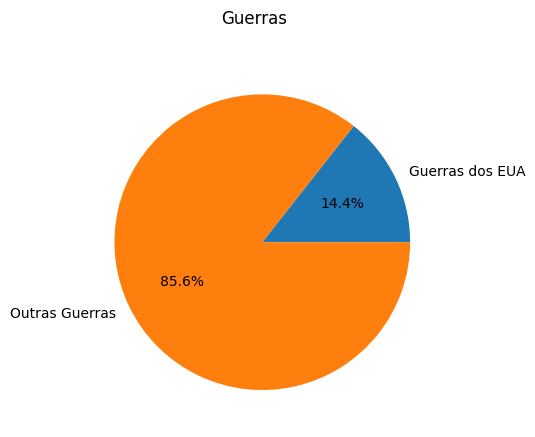

In [121]:
#quantos % de guerra do banco os EUA se envolveram?
total_guerras = df[df['intensity_level']== 'war']['conflict_id'].nunique()
filtro_eua = (df['intensity_level'] == 'war') & (
    (df['side_a'].str.contains('Government of United States', na=False)) | 
    (df['side_b'].str.contains('Government of United States', na=False)) |
    (df['side_a_2nd'].str.contains('Government of United States', na=False)) | 
    (df['side_b_2nd'].str.contains('Government of United States', na=False))
)
guerras_eua = df[filtro_eua]['conflict_id'].nunique()

porcentagem = (guerras_eua / total_guerras)*100
outros = total_guerras - guerras_eua
print(f"Total de guerras no banco: {total_guerras}")
print(f"Guerras com participação dos EUA: {guerras_eua}")
print(f"Porcentagem de guerras dos EUA: {porcentagem:.2f}%")

resumo_pizza = pd.Series([guerras_eua, outros ], index = ['Guerras dos EUA', 'Outras Guerras'])
resumo_pizza.plot.pie(subplots=True, autopct = '%1.1f%%', title = "Guerras")

Guerras de Israel: 6
Outras guerras: 126
Total de guerras: 132


array([<Axes: >], dtype=object)

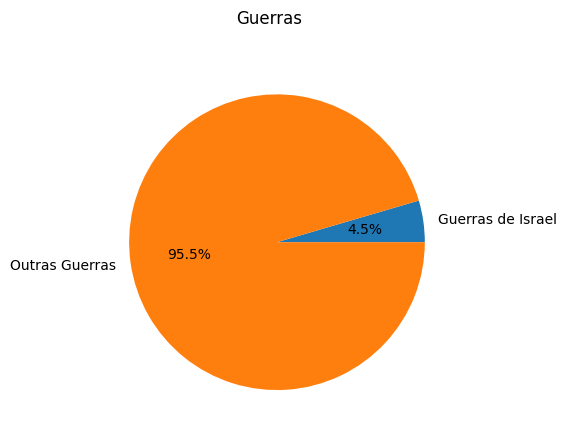

In [22]:
#plotar um grafico da porcentagem de guerras de israel
israel = df[(df['side_a'] == 'Government of Israel') & (df['intensity_level'] == 'war') | (df['side_b'] == 'Government of Israel') & (df['intensity_level'] == 'war')]
guerras_israel = israel['conflict_id'].nunique()
total_guerras = df[df['intensity_level']== 'war']['conflict_id'].nunique()
outras = total_guerras - guerras_israel
print(f'Guerras de Israel: {guerras_israel}')
print(f'Outras guerras: {outras}')
print(f'Total de guerras: {total_guerras}')
resumo_pizza = pd.Series([guerras_israel, outros], index = ['Guerras de Israel', 'Outras Guerras'])
resumo_pizza.plot.pie(subplots=True, autopct = '%1.1f%%', title = "Guerras")
